# Tech Challenge - Fase 1
## Integrantes
- Gabriel Fontineles
- Gabriel Kendy Sato
- Josilene Oliveira Afonso
- Katia Oliveira da Silva Costa
- Yasmim de Oliveira Coelho

## 1. Entendimento do Negócio
- Qual problema de negócio está sendo resolvido?

#### O problema de negócio consiste em compreender os fatores que influenciam a satisfação dos clientes de um e-commerce, medida por meio do Net Promoter Score (NPS). O desafio é identificar antecipadamente quais clientes estão caminhando para se tornarem detratores, usando dados operacionais já disponíveis.

- Por que o NPS é importante para um e-commerce?

#### No e-commerce, o custo de aquisição de cliente é alto. Um promotor tende a recomprar mais, gasta mais por pedido e indica novos clientes sem custo para a empresa. Um detrator cancela compras, aciona SAC, deixa avaliações negativas e migra para concorrentes. Um ponto de NPS perdido tem impacto direto em receita recorrente.

- Quais áreas poderiam se beneficiar desses insights? Exemplos: logística, atendimento, pricing, produto etc.


#### Os resultados desta análise podem apoiar diversas áreas da empresa, entre elas:

Logística: otimização dos processos de entrega, com foco na redução de atrasos e falhas, garantindo maior confiabilidade na experiência do cliente.

Atendimento ao Cliente: aprimoramento da qualidade do suporte, com redução do tempo de resolução de problemas e diminuição do volume de contatos recorrentes.

Operações: identificação de gargalos críticos na jornada de compra, possibilitando ajustes que aumentam a eficiência operacional e reduzem fricções.

- Como o NPS impacta:

Recompra: Promotores compram com mais frequência e maior ticket médio.

Boca a boca: Cada promotor tende a trazer novos clientes organicamente, reduzindo o CAC sem investimento em mídia.

Market share em e-commerce: Alta lealdade cria barreiras de saída naturais, dificultando migração para concorrentes e protegendo receita.

# 2. Definição da Target: qual é o alvo desse problema de negócio?  
- Qual variável representa a satisfação do cliente?

A variável que representa a satisfação do cliente é nps_score, que corresponde à nota atribuída pelo cliente ao final da sua experiência de compra

- Por que ela foi escolhida?

A variável nps_score foi escolhida por ser o indicador oficial de satisfação disponibilizado na base de dados. Além disso, o NPS é amplamente utilizado pelo mercado para avaliar a percepção dos clientes sobre produtos e serviços, permitindo identificar clientes promotores, neutros e detratores.

- Em que momento da jornada essa informação é coletada?

De acordo com o contexto do desafio, o NPS é coletado após o encerramento da jornada de compra, quando o cliente já recebeu seu pedido e teve sua experiência concluída. Dessa forma, a nota reflete a percepção geral do cliente sobre todo o processo de compra.

- Existe algum risco de usar essa variável de forma inadequada?

Sim. O NPS representa uma percepção subjetiva do cliente e pode ser influenciado por fatores externos que não estão diretamente relacionados à qualidade do serviço prestado. Além disso, utilizar apenas o NPS sem analisar variáveis operacionais pode levar a conclusões equivocadas sobre as causas da satisfação ou insatisfação dos clientes.

## 1. Validação da qualidade dos dados

In [25]:
#Importando bibliotecas
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Carregando a base de dados direto do GitHub
df = pd.read_csv("desafio_nps_fase_1.csv")


In [27]:
# Paleta
AZUL = "#2C5F8A"; VERM = "#C0392B"; CINZA = "#7F8C8D"; VERDE = "#27AE60"

## 2. Reconhecimento da Estrutura da Base

In [28]:
# Prévia da tabela
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [29]:
# Verificação de valores nulos
nulos = df.isnull().sum().sum()
print(f"Valores nulos: {nulos}")

Valores nulos: 0


In [30]:
# Verificação de dimensões
linhas, colunas = df.shape
print(f"Linhas: {linhas}")
print(f"Colunas: {colunas}")

Linhas: 2500
Colunas: 19


In [31]:
# Verificação de duplicados
duplicados = df.duplicated().sum().sum()
print(f"Valores duplicados: {duplicados}")

Valores duplicados: 0


In [32]:
df.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='object')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [34]:
#Validando se existe algum valor logicamente impossível

print("Idade fora de 0-120:", ((df.customer_age<0)|(df.customer_age>120)).sum())
print("NPS fora de 0-10:", ((df.nps_score<0)|(df.nps_score>10)).sum())
print("CSAT fora de 0-10:", ((df.csat_internal_score<0)|(df.csat_internal_score>10)).sum())
print("order_value negativo:", (df.order_value<0).sum())
print("delivery_delay_days negativo:", (df.delivery_delay_days<0).sum())

Idade fora de 0-120: 0
NPS fora de 0-10: 0
CSAT fora de 0-10: 0
order_value negativo: 0
delivery_delay_days negativo: 0


## 3. Estatísticas descritivas das variáveis de interesse

In [35]:
df[['nps_score','customer_service_contacts', 'resolution_time_days','delivery_delay_days']].describe().round(2)

,nps_score,customer_service_contacts,resolution_time_days,delivery_delay_days
count,2500.00,2500.00,2500.00,2500.00
mean,4.38,1.52,5.49,2.19
std,2.51,1.23,3.46,1.45
min,0.00,0.00,0.00,0.00
25%,2.60,1.00,2.00,1.00
50%,4.40,1.00,6.00,2.00
75%,6.10,2.00,8.00,3.00
max,10.00,7.00,11.00,8.00


## 4. Classificando a NPS


O nps_score (0 a 10) é a variável que representa a satisfação do cliente.

Será classificada conforme abaixo:

* Detratores: nota 0 a 6
* Neutros: nota 7 a 8
* Promotores: nota 9 a 10

In [36]:
def classificar_nps(nota):
    if nota <= 6:
        return 'Detrator'
    elif nota <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

df['nps_cat'] = pd.Categorical(
    df['nps_score'].apply(classificar_nps),
    categories=['Detrator', 'Neutro', 'Promotor'], ordered=True
)

print(df['nps_score'].describe().round(2))
print()
print(df['nps_cat'].value_counts())
print()
print((df['nps_cat'].value_counts(normalize=True)*100).round(1))

# NPS líquido = %Promotores - %Detratores
nps_liquido = (df['nps_cat'].eq('Promotor').mean() - df['nps_cat'].eq('Detrator').mean()) * 100
print(f"\nNPS líquido = {nps_liquido:.0f}")

count    2500.00
mean        4.38
std         2.51
min         0.00
25%         2.60
50%         4.40
75%         6.10
max        10.00
Name: nps_score, dtype: float64

nps_cat
Detrator    1851
Neutro       448
Promotor     201
Name: count, dtype: int64

nps_cat
Detrator    74.0
Neutro      17.9
Promotor     8.0
Name: proportion, dtype: float64

NPS líquido = -66


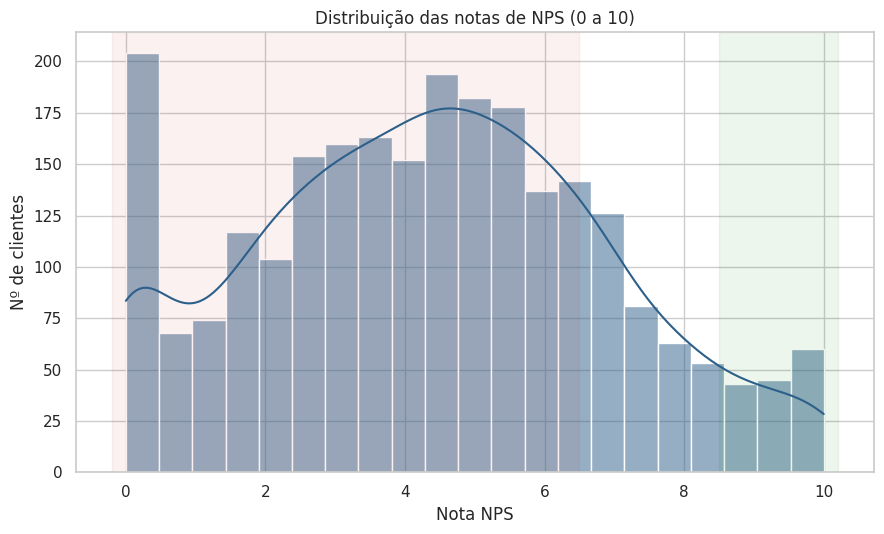

In [37]:
#Configurações do Gráfico
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5.5)
pd.set_option("display.max_columns", 30)

#Gráfico com a distribuição das notas de
fig, ax = plt.subplots()
sns.histplot(df['nps_score'], bins=21, kde=True, color=AZUL, ax=ax)
ax.axvspan(-0.2, 6.5, alpha=0.07, color=VERM)
ax.axvspan(8.5, 10.2, alpha=0.07, color='green')
ax.set_title("Distribuição das notas de NPS (0 a 10)")
ax.set_xlabel("Nota NPS"); ax.set_ylabel("Nº de clientes")
plt.tight_layout(); plt.show()


**Achado 1 — O NPS está crítico.**

 A nota média é 4,38, com 74% de detratores, 18% neutros e apenas 8% promotores. O NPS líquido é -66, um valor muito baixo. A distribuição é assimétrica à esquerda (concentrada nas notas baixas). Isso confirma a dor de negócio: **a empresa tem um problema real de satisfação**.

## 5. Análise das causas do NPS

Deixamos de olhar as variáveis isoladamente e investigamos **como elas se relacionam com o NPS**.
Começamos pela matriz de correlação.

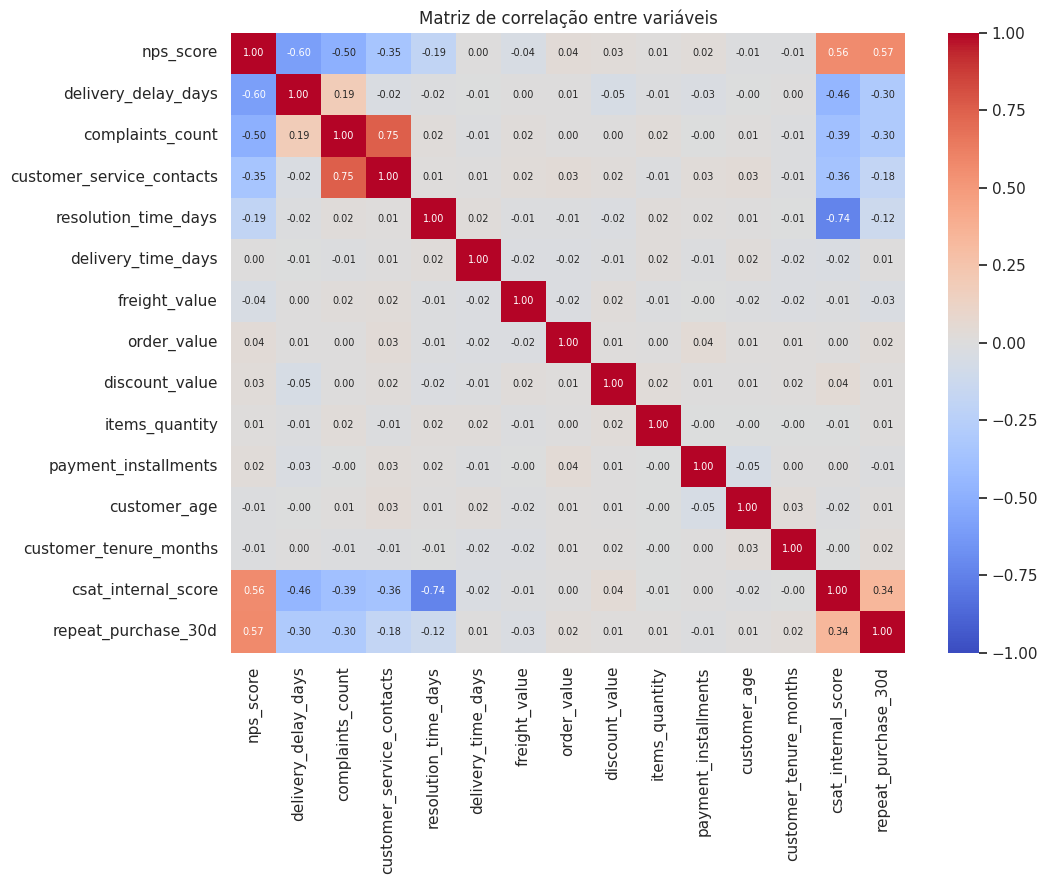

In [38]:
num = ['nps_score','delivery_delay_days','complaints_count','customer_service_contacts',
       'resolution_time_days','delivery_time_days','freight_value','order_value','discount_value',
       'items_quantity','payment_installments','customer_age','customer_tenure_months',
       'csat_internal_score','repeat_purchase_30d']

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df[num].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax, annot_kws={"size":7})
ax.set_title("Matriz de correlação entre variáveis")
plt.tight_layout(); plt.show()

### 5.1 Leakage: csat_internal_score e repeat_purchase_30d

Duas variáveis têm correlação alta com o NPS, mas precisam de cuidado conceitual

- `repeat_purchase_30d`: recompra **em até 30 dias após o pedido** — é um evento **posterior** à compra.
- `csat_internal_score`: score interno de satisfação — medido junto/depois da experiência.

Como o objetivo de negócio é **antecipar o NPS antes da pesquisa**, usar essas variáveis como "explicação"
seria **vazamento temporal**: são informações que ainda não existiriam no momento em que queremos agir.
Por isso, as **excluímos da análise de fatores operacionais acionáveis** e focamos nas variáveis de
pedido, logística e atendimento.

In [39]:
# Verificando o comportamento suspeito de leakage
print("repeat_purchase_30d (taxa) por categoria de NPS:")
print(df.groupby('nps_cat', observed=True)['repeat_purchase_30d'].mean().round(3))
print("\ncsat_internal_score médio por categoria de NPS:")
print(df.groupby('nps_cat', observed=True)['csat_internal_score'].mean().round(2))

repeat_purchase_30d (taxa) por categoria de NPS:
nps_cat
Detrator    0.000
Neutro      0.038
Promotor    1.000
Name: repeat_purchase_30d, dtype: float64

csat_internal_score médio por categoria de NPS:
nps_cat
Detrator    2.34
Neutro      4.23
Promotor    5.60
Name: csat_internal_score, dtype: float64


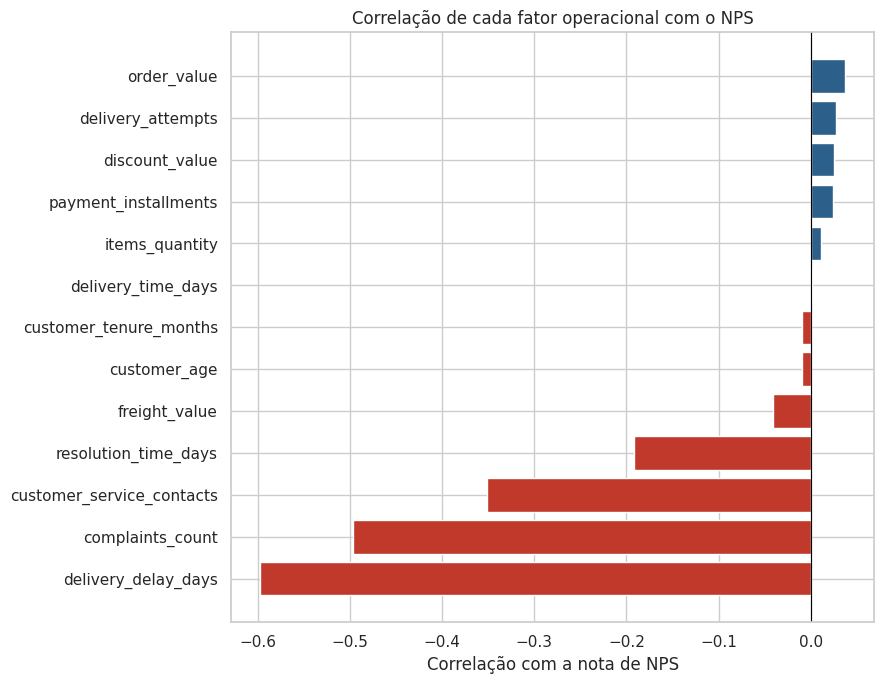

,nps_score
delivery_delay_days,-0.597
complaints_count,-0.497
customer_service_contacts,-0.351
resolution_time_days,-0.191
freight_value,-0.041
customer_age,-0.010
customer_tenure_months,-0.010
delivery_time_days,0.001
items_quantity,0.011
payment_installments,0.024


In [40]:
# Correlação apenas dos fatores OPERACIONAIS acionáveis com o NPS
drivers = ['delivery_delay_days','complaints_count','customer_service_contacts','resolution_time_days',
           'freight_value','order_value','discount_value','items_quantity','payment_installments',
           'customer_age','customer_tenure_months','delivery_time_days','delivery_attempts']
corr = df[drivers+['nps_score']].corr()['nps_score'].drop('nps_score').sort_values()

fig, ax = plt.subplots(figsize=(9,7))
ax.barh(corr.index, corr.values, color=[VERM if v<0 else AZUL for v in corr.values])
ax.axvline(0, color='black', lw=0.8)
ax.set_title("Correlação de cada fator operacional com o NPS")
ax.set_xlabel("Correlação com a nota de NPS")
plt.tight_layout(); plt.show()
corr.round(3)

**Achado 2 — Os três fatores que mais derrubam o NPS são, em ordem:**
1. **Atraso na entrega** (`delivery_delay_days`): correlação **-0,60** — o fator mais forte.
2. **Reclamações** (`complaints_count`): correlação **-0,50**.
3. **Contatos com o atendimento** (`customer_service_contacts`): correlação **-0,35**.

Já valor do pedido, frete, desconto, idade, tempo de casa e região têm correlação **próxima de zero** —
ou seja, **não é o perfil do cliente nem o valor da compra que determinam a satisfação, e sim a experiência operacional** (principalmente a logística).

### 5.2 O ponto de ruptura: atraso na entrega

                     mean  count
delivery_delay_days             
0                    6.86    277
1                    5.55    615
2                    4.58    646
3                    3.44    525
4                    2.44    270
5                    1.48    116
6                    1.10     34
7                    0.29     14
8                    0.00      3


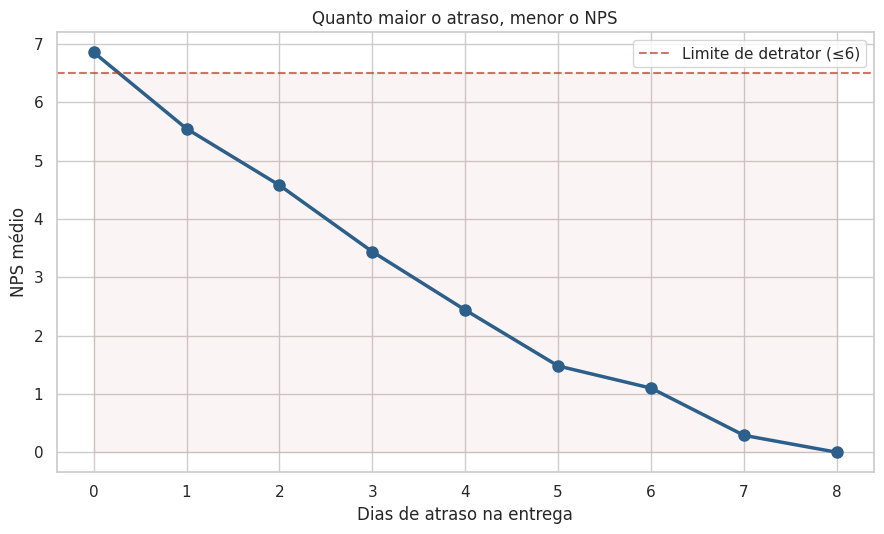

In [41]:
g = df.groupby('delivery_delay_days')['nps_score'].agg(['mean','count']).round(2)
print(g)

fig, ax = plt.subplots()
ax.plot(g.index, g['mean'], marker='o', color=AZUL, lw=2.5, markersize=8)
ax.axhline(6.5, color=VERM, ls='--', alpha=0.7, label='Limite de detrator (≤6)')
ax.fill_between(g.index, 0, 6.5, alpha=0.05, color=VERM)
ax.set_title("Quanto maior o atraso, menor o NPS")
ax.set_xlabel("Dias de atraso na entrega"); ax.set_ylabel("NPS médio"); ax.legend()
plt.tight_layout(); plt.show()

In [42]:
# % de detratores por dia de atraso
pct_det = df.groupby('delivery_delay_days')['nps_cat'].apply(lambda s:(s=='Detrator').mean()*100).round(1)
print("% de detratores por dia de atraso:")
print(pct_det)

% de detratores por dia de atraso:
delivery_delay_days
0     36.5
1     59.7
2     75.4
3     89.7
4     95.9
5     99.1
6    100.0
7    100.0
8    100.0
Name: nps_cat, dtype: float64


**Achado 3 — Existe um ponto de ruptura claro.** Sem atraso, o NPS médio é **6,9** (na fronteira de promotor)
e apenas 37% são detratores. **A partir de 2 dias de atraso, a maioria já vira detratora (75%)**, e com 3 dias
ou mais o NPS médio cai abaixo de 3,5 e os detratores passam de 90%. Cada dia de atraso retira,
em média, cerca de **1 ponto** do NPS. **Os 2 primeiros dias de atraso são o intervalo mais crítico** —
é onde a experiência "quebra".

### 5.3 Reclamações e atendimento

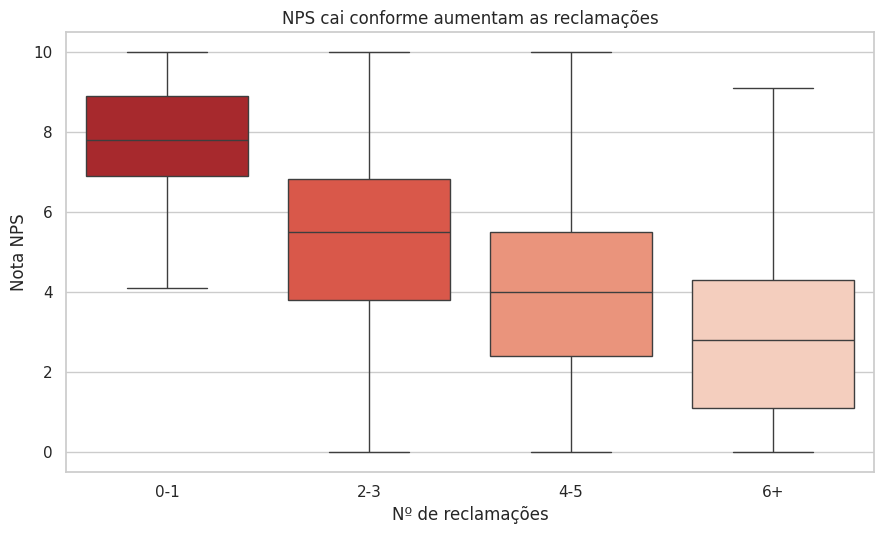

In [43]:
#Gráfico de boxplot
fig, ax = plt.subplots()
df['faixa_recl'] = pd.cut(df['complaints_count'], [-1,1,3,5,20], labels=['0-1','2-3','4-5','6+'])
sns.boxplot(data=df, x='faixa_recl', y='nps_score', hue='faixa_recl', palette='Reds_r', legend=False, ax=ax)
ax.set_title("NPS cai conforme aumentam as reclamações")
ax.set_xlabel("Nº de reclamações"); ax.set_ylabel("Nota NPS")
plt.tight_layout(); plt.show()

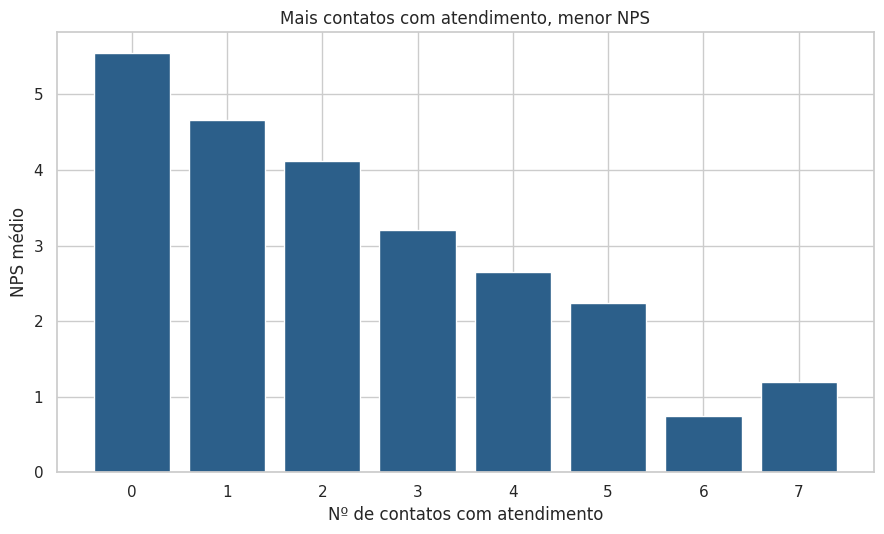

In [44]:
fig, ax = plt.subplots()
g = df.groupby('customer_service_contacts')['nps_score'].mean()
ax.bar(g.index, g.values, color=AZUL)
ax.set_title("Mais contatos com atendimento, menor NPS")
ax.set_xlabel("Nº de contatos com atendimento"); ax.set_ylabel("NPS médio")
plt.tight_layout(); plt.show()

**Achado 4 — Atendimento é sintoma e agravante.** Clientes sem reclamações têm NPS ~8,5; com 5+ reclamações,
cai para ~3,5. O mesmo vale para contatos com o atendimento: cada novo contato acompanha uma queda no NPS.
Recorrer ao atendimento, na base, está associado a uma experiência que já deu errado — e quanto mais o cliente
precisa insistir, pior fica.

### 5.4 O efeito combinado das dores

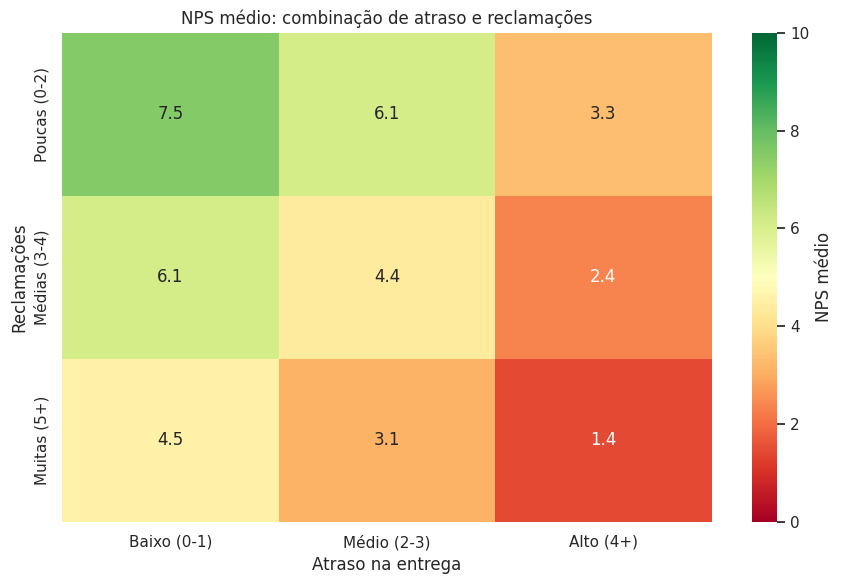

In [45]:
fig, ax = plt.subplots(figsize=(9,6))
df['fa'] = pd.cut(df['delivery_delay_days'], [-1,1,3,10], labels=['Baixo (0-1)','Médio (2-3)','Alto (4+)'])
df['fr'] = pd.cut(df['complaints_count'], [-1,2,4,20], labels=['Poucas (0-2)','Médias (3-4)','Muitas (5+)'])
piv = df.pivot_table(values='nps_score', index='fr', columns='fa', aggfunc='mean')
sns.heatmap(piv, annot=True, fmt=".1f", cmap="RdYlGn", vmin=0, vmax=10, ax=ax, cbar_kws={'label':'NPS médio'})
ax.set_title("NPS médio: combinação de atraso e reclamações")
ax.set_xlabel("Atraso na entrega"); ax.set_ylabel("Reclamações")
plt.tight_layout(); plt.show()

**Achado 5 — As dores se somam.** Um cliente com pouco atraso e poucas reclamações tem NPS ~6,5 (perto de promotor);
um cliente com atraso alto e muitas reclamações tem NPS ~2,0. O pior cenário não é uma dor isolada, mas a
**combinação de falha logística + recorrência de problemas**.

### 5.5 O perfil do cliente importa? (região, idade, tempo de casa)

In [46]:
print("NPS médio por região:")
print(df.groupby('customer_region')['nps_score'].mean().round(2).sort_values())

NPS médio por região:
customer_region
Centro-Oeste    4.21
Sudeste         4.37
Norte           4.38
Nordeste        4.42
Sul             4.49
Name: nps_score, dtype: float64


**Achado 6 — O perfil do cliente quase não importa.** O NPS médio é praticamente igual entre as cinco regiões
(4,2 a 4,5), e idade e tempo de relacionamento têm correlação com o NPS. Isso é uma **boa notícia para o negócio**:
o problema **não** está em "que tipo de cliente" temos, e sim na **operação** — algo sobre o qual a empresa tem controle direto.

## 6. Conclusão

A análise mostra que a baixa satisfação do e-commerce é **operacional e, portanto, acionável**. O **atraso na
entrega** é o fator de maior impacto, seguido de **reclamações** e **contatos com o atendimento**. Existe um
**ponto de ruptura a partir de 2 dias de atraso**, e as dores se somam. O perfil do cliente (região, idade,
tempo de casa) praticamente não influencia o NPS.
